# Predicting Marketing Campaign Response
### A customer-response model, and what it tells the marketing team to do next

**Author:** Data Science Candidate &nbsp;•&nbsp; **Dataset:** Kaggle *Marketing Campaign* (2,240 retail customers)

---

A retailer ran a campaign — an offer pushed to thousands of customers — and recorded who took it up.
Only about **1 in 7 customers said yes.** Contacting everyone is expensive and a little annoying for the
6 in 7 who never bite. This notebook builds a model that scores each customer's *likelihood to respond*,
then turns that score into concrete marketing decisions: who to target, where to spend, and what to expect.

I deliberately split my time the way the business would want it: a solid model, but with the bulk of the
effort on **what the findings mean for revenue.** Every chart below is followed by a plain-language read,
and the technical results are always translated back into a marketing action.

**How to read this notebook**

| # | Section | What you get |
|---|---------|--------------|
| 1 | Project Overview | The problem, the goal, and how we judge success |
| 2 | Data Loading & Understanding | What's in the data and what's wrong with it |
| 3 | Exploratory Data Analysis | The patterns, with **5+ business insights** |
| 4 | Feature Engineering | New signals we build from the raw columns |
| 5 | Data Preprocessing | Leakage-free preparation for modelling |
| 6 | Model Building | Logistic Regression, Random Forest, XGBoost |
| 7 | Model Evaluation | Head-to-head metrics and the winner |
| 8 | Marketing Perspective | Which metric actually matters, and why |
| 9 | Feature Importance | What drives a "yes" |
| 10 | Business Recommendations | The action plan for leadership |
| 11 | Deployment Risks | What could go wrong in production |
| 12 | Future Improvements | What I'd do with one more week |
| 13 | Executive Summary | The one-pager for a Marketing Director |

# 1 — Project Overview

**The business problem.** Marketing budget is finite and every contact has a cost (a mailer, a call, a
discount that eats margin). When a campaign goes out to the entire customer base, most of the money is
spent on people who were never going to respond. The team wants to stop spraying and start *targeting*.

**The ML objective.** A binary classification model: given everything we know about a customer, predict
the probability that they will accept the next campaign offer (`Response` = 1) versus ignore it
(`Response` = 0). The probability — not just the yes/no — is the useful output, because it lets us rank
customers and contact them in priority order until the budget runs out.

**Success criteria.**

- *Statistical:* rank customers well enough that a model-driven contact list beats random contacting by a
  wide margin. We track **ROC-AUC** (ranking quality) and **Recall** (share of true responders we catch),
  not raw accuracy — with an 85/15 class split, a model that predicts "no" for everyone is 85% accurate
  and 100% useless.
- *Business:* a contact strategy that reaches most of the responders while cutting wasted contacts, and a
  short list of customer traits the team can act on immediately.

**Why this matters to marketing teams.** Two numbers frame everything: the **cost of a wasted contact**
(a false positive) and the **value of a missed responder** (a false negative). A good model shifts spend
away from the first and toward the second. Concretely, it answers the only three questions a marketing
director cares about: *Who do we call first? How much do we spend? What lift do we get for it?*

## Setup

Standard scientific-Python stack. The styling block just makes every chart legible at a glance — a
consistent palette where **coral always means "responded"** and grey means "did not".

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)
np.random.seed(42)

# A small, consistent visual identity for the whole notebook.
NAVY, BLUE, TEAL = "#1F3A5F", "#2E6F9E", "#3FA7A0"
CORAL, GREY, GOLD = "#E8743B", "#9AA7B2", "#F2B134"
RESP_PALETTE = {0: GREY, 1: CORAL}      # 0 = ignored, 1 = responded
SEQ = [NAVY, BLUE, TEAL, GOLD, CORAL]

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "axes.edgecolor": "#cccccc",
    "font.size": 11,
    "legend.frameon": False,
})

def pct_axis(ax, axis="y"):
    # Format an axis as whole-number percentages.
    fmt = mtick.PercentFormatter(xmax=1.0, decimals=0)
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

print("Environment ready.")

Environment ready.


# 2 — Data Loading & Understanding

The file is semicolon-separated and carries a UTF-8 byte-order mark, so we pass `sep=";"` and
`encoding="utf-8-sig"`. If the local copy is missing (e.g. a fresh Google Colab runtime), we fall back to
the public raw URL so the notebook always runs end-to-end.

In [2]:
LOCAL_PATH = "../data/marketing_campaign.csv"
RAW_URL = ("https://raw.githubusercontent.com/nurimammasri/"
           "Marketing-Campaign-Model-Prediction-by-Datalicious/main/"
           "data/marketing_campaign.csv")

source = LOCAL_PATH if os.path.exists(LOCAL_PATH) else RAW_URL
raw = pd.read_csv(source, sep=";", encoding="utf-8-sig")
print(f"Loaded {raw.shape[0]:,} customers x {raw.shape[1]} columns from "
      f"{'local file' if source == LOCAL_PATH else 'remote URL'}")

Loaded 2,240 customers x 29 columns from local file


## Dataset Overview

One row per customer. The columns fall into five natural groups — knowing these groups is half the battle:

| Group | Columns | What it captures |
|-------|---------|------------------|
| **Identity** | `ID` | Unique key (not predictive) |
| **Demographics** | `Year_Birth`, `Education`, `Marital_Status`, `Income`, `Kidhome`, `Teenhome`, `Dt_Customer` | Who the customer is and when they joined |
| **Recency** | `Recency` | Days since their last purchase |
| **Spending (2 yrs)** | `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` | Money spent per product category |
| **Purchasing & channels** | `NumDealsPurchases`, `NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases`, `NumWebVisitsMonth` | How and how often they buy |
| **Campaign history** | `AcceptedCmp1`–`AcceptedCmp5`, `Complain` | How they reacted to past offers |
| **Target** | `Response` | **1 = accepted the latest campaign, 0 = ignored it** |

`Z_CostContact` and `Z_Revenue` are bookkeeping constants (cost = 3, revenue = 11 per offer) — we'll put
those economics to good use later in the Marketing Perspective.

In [3]:
raw.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

### Target distribution

The first thing to check in any response problem: how (im)balanced is the target? This single number
shapes every modelling decision that follows.

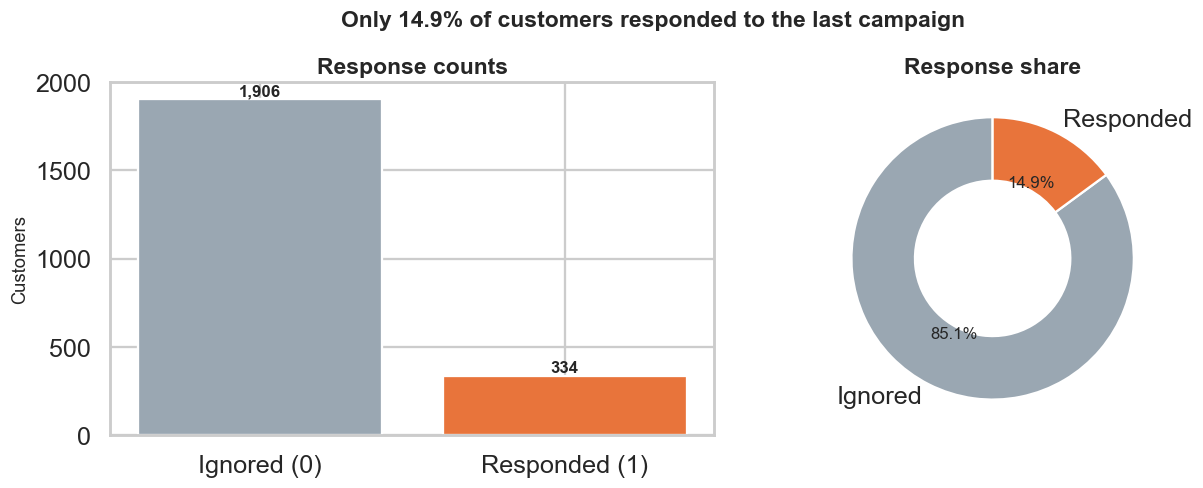

In [5]:
counts = raw["Response"].value_counts().sort_index()
rate = raw["Response"].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(["Ignored (0)", "Responded (1)"], counts.values, color=[GREY, CORAL])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 20, f"{v:,}", ha="center", fontweight="bold")
ax[0].set_title("Response counts")
ax[0].set_ylabel("Customers")

ax[1].pie(counts.values, labels=["Ignored", "Responded"], colors=[GREY, CORAL],
          autopct="%1.1f%%", startangle=90, wedgeprops=dict(width=0.45))
ax[1].set_title("Response share")
plt.suptitle(f"Only {rate:.1%} of customers responded to the last campaign",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Read:** about **15% responders to 85% non-responders** — a ~5.7-to-1 imbalance. Two consequences we
carry forward: (1) *accuracy is a trap* (predicting "no" for everyone scores 85%), so we lean on ROC-AUC
and recall instead; and (2) the models must be told to **weight the minority class** or they'll happily
ignore the very customers we care about.

## Data Quality Checks

Before trusting any pattern, find out where the data lies to us. We check five things: missing values,
duplicates, wrong datatypes, outliers, and category inconsistencies.

In [6]:
# 1) Missing values
missing = raw.isna().sum()
missing = missing[missing > 0].to_frame("missing")
missing["pct"] = (missing["missing"] / len(raw) * 100).round(2)
print("Columns with missing values:")
print(missing)
print("\nEverything else is complete.")

Columns with missing values:
        missing   pct
Income       24  1.07

Everything else is complete.


**Read:** only `Income` is missing, for **24 customers (~1.1%)**. That's small and almost certainly
*missing at random* (a few records where income wasn't captured), so we can impute it safely — but we'll
do that *inside the modelling pipeline* so the fill value is learned only from training data.

In [7]:
# 2) Duplicates
print("Duplicate IDs        :", raw["ID"].duplicated().sum())
print("Fully duplicate rows :", raw.duplicated().sum())

Duplicate IDs        : 0
Fully duplicate rows : 0


**Read:** no duplicate customers and no repeated rows — the grain of the data is clean (one row per
person).

In [8]:
# 3) Datatypes worth fixing
print(raw[["Dt_Customer", "Income", "Year_Birth"]].dtypes)
print("\nDt_Customer is stored as text, e.g.:", raw["Dt_Customer"].iloc[0])
print("Z_CostContact unique values:", raw["Z_CostContact"].unique(),
      "| Z_Revenue unique values:", raw["Z_Revenue"].unique())

Dt_Customer        str
Income         float64
Year_Birth       int64
dtype: object

Dt_Customer is stored as text, e.g.: 2012-09-04
Z_CostContact unique values: [3] | Z_Revenue unique values: [11]


**Read:** `Dt_Customer` (enrolment date) is text and needs parsing to a real date before we can compute
tenure. `Z_CostContact` and `Z_Revenue` are **constant** (3 and 11) — zero predictive value, so they get
dropped (though we'll reuse those numbers as the campaign's unit economics).

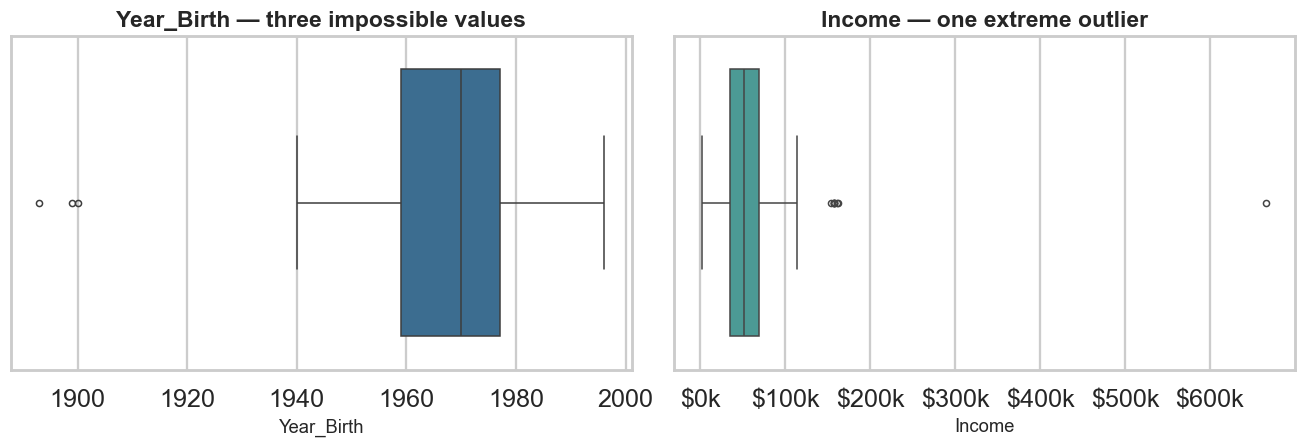

Oldest 'birth years': [np.int64(1893), np.int64(1899), np.int64(1900), np.int64(1940), np.int64(1941)] -> implied ages of 115+; data-entry errors.
Top incomes        : [np.float64(160803.0), np.float64(162397.0), np.float64(666666.0)] -> $666,666 is ~4x the next earner; an error.


In [9]:
# 4) Outliers — Year_Birth and Income
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.boxplot(x=raw["Year_Birth"], ax=ax[0], color=BLUE, fliersize=4)
ax[0].set_title("Year_Birth — three impossible values")
sns.boxplot(x=raw["Income"], ax=ax[1], color=TEAL, fliersize=4)
ax[1].set_title("Income — one extreme outlier")
ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
plt.tight_layout()
plt.show()

print("Oldest 'birth years':", sorted(raw["Year_Birth"].unique())[:5],
      "-> implied ages of 115+; data-entry errors.")
print("Top incomes        :", sorted(raw["Income"].dropna().unique())[-3:],
      "-> $666,666 is ~4x the next earner; an error.")

**Read:** three customers were "born" before 1900 (implied age 115+) and one reports a **\$666,666**
income that sits about four times above the next-highest earner. These are data-entry errors, not real
extremes — we'll remove those few rows so they don't distort age and income statistics.

In [10]:
# 5) Category inconsistencies
print("Marital_Status:\n", raw["Marital_Status"].value_counts(), "\n")
print("Education:\n", raw["Education"].value_counts())

Marital_Status:
 Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Education:
 Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


**Read:** `Marital_Status` has junk labels — `Alone` (3), `Absurd` (2), `YOLO` (2). `Alone` is really
*Single*; `Absurd`/`YOLO` are nonsense entries we'll bucket into *Other*. `Education` is clean, just using
European labels (`2n Cycle` = Master's-equivalent, `Basic` = primary).

### Data-quality verdict (plain English)

This is a **clean, well-behaved dataset**. The only real work is: drop two dead columns, parse one date,
remove a handful of error rows, tidy a few marital-status labels, and let the pipeline fill 24 missing
incomes. No heroic cleaning required — which means we can trust the patterns we find next.

# 3 — Exploratory Data Analysis

We now apply the cleaning identified above and build a set of engineered features (detailed in Section 4)
so the EDA can speak in business terms — *total spending*, *income tier*, *prior campaigns accepted* —
rather than raw columns. Then we look at demographics, spending, campaign behaviour, and finally compare
responders against non-responders.

In [11]:
def clean_data(df):
    # Structural cleaning only — see Section 2 for the justification of each step.
    df = df.copy()
    df = df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"])
    df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")
    df = df[df["Year_Birth"] >= 1900]                              # drop impossible ages
    df = df[(df["Income"].isna()) | (df["Income"] < 600_000)]      # drop the income error
    df["Marital_Status"] = df["Marital_Status"].astype("object").replace(
        {"Alone": "Single", "Absurd": "Other", "YOLO": "Other"})
    df["Education"] = df["Education"].astype("object")
    return df.reset_index(drop=True)

SPEND = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
         "MntSweetProducts", "MntGoldProds"]
BUY = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumDealsPurchases"]
CMP = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]
SNAPSHOT = pd.Timestamp("2015-01-01")   # enrolment ends mid-2014; freeze the clock here

def engineer_features(df):
    df = df.copy()
    df["Age"] = 2015 - df["Year_Birth"]
    df["Children"] = df["Kidhome"] + df["Teenhome"]
    df["HasChildren"] = (df["Children"] > 0).astype(int)
    df["TotalSpending"] = df[SPEND].sum(axis=1)
    df["TotalPurchases"] = df[BUY].sum(axis=1)
    df["SpendingPerPurchase"] = np.where(df["TotalPurchases"] > 0,
                                          df["TotalSpending"] / df["TotalPurchases"], 0.0)
    df["TotalAcceptedCmp"] = df[CMP].sum(axis=1)
    df["Customer_Tenure_Years"] = (SNAPSHOT - df["Dt_Customer"]).dt.days / 365.25
    df["EngagementScore"] = df["TotalPurchases"] + 3 * df["TotalAcceptedCmp"]
    df["IncomeSegment"] = pd.cut(df["Income"], [-np.inf, 35_000, 70_000, np.inf],
                                 labels=["Low", "Medium", "High"])
    df["AgeGroup"] = pd.cut(df["Age"], [0, 35, 50, 65, np.inf],
                            labels=["<=35", "36-50", "51-65", "65+"])
    return df

df = engineer_features(clean_data(raw))
overall_rate = df["Response"].mean()
print(f"After cleaning: {df.shape[0]:,} customers, {df.shape[1]} columns "
      f"(removed {len(raw) - len(df)} error rows).")
print(f"Overall response rate: {overall_rate:.1%}")

After cleaning: 2,237 customers, 37 columns (removed 3 error rows).
Overall response rate: 14.9%


### Demographics — who are these customers?

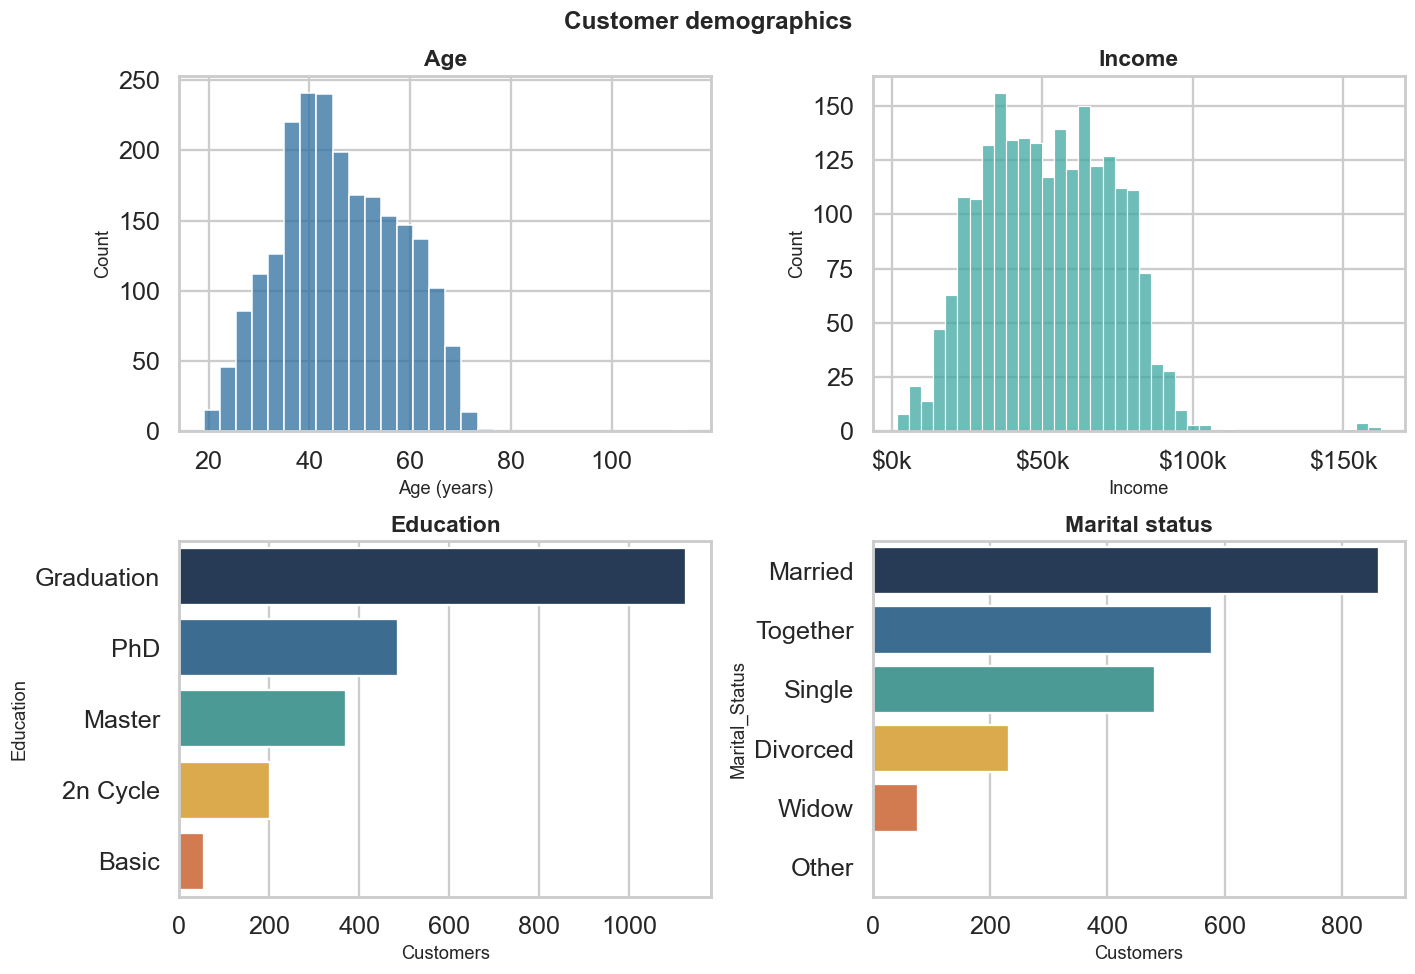

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df["Age"], bins=30, color=BLUE, ax=ax[0, 0])
ax[0, 0].set_title("Age")
ax[0, 0].set_xlabel("Age (years)")

sns.histplot(df["Income"].dropna(), bins=40, color=TEAL, ax=ax[0, 1])
ax[0, 1].set_title("Income")
ax[0, 1].set_xlabel("Income")
ax[0, 1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))

edu = df["Education"].value_counts()
sns.barplot(x=edu.values, y=edu.index, ax=ax[1, 0], palette=SEQ, hue=edu.index, legend=False)
ax[1, 0].set_title("Education")
ax[1, 0].set_xlabel("Customers")

mar = df["Marital_Status"].value_counts()
sns.barplot(x=mar.values, y=mar.index, ax=ax[1, 1], palette=SEQ, hue=mar.index, legend=False)
ax[1, 1].set_title("Marital status")
ax[1, 1].set_xlabel("Customers")

plt.suptitle("Customer demographics", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Read:** a mature, fairly affluent base. Ages cluster in the **40–60** range, income is roughly bell-shaped
around **\$50k** (a long right tail of high earners), and the typical customer is a **university graduate**
who is **married or living with a partner**. This is a customer base with disposable income — the campaign's
job is to find the slice most willing to spend it.

### Spending behaviour — where does the money go?

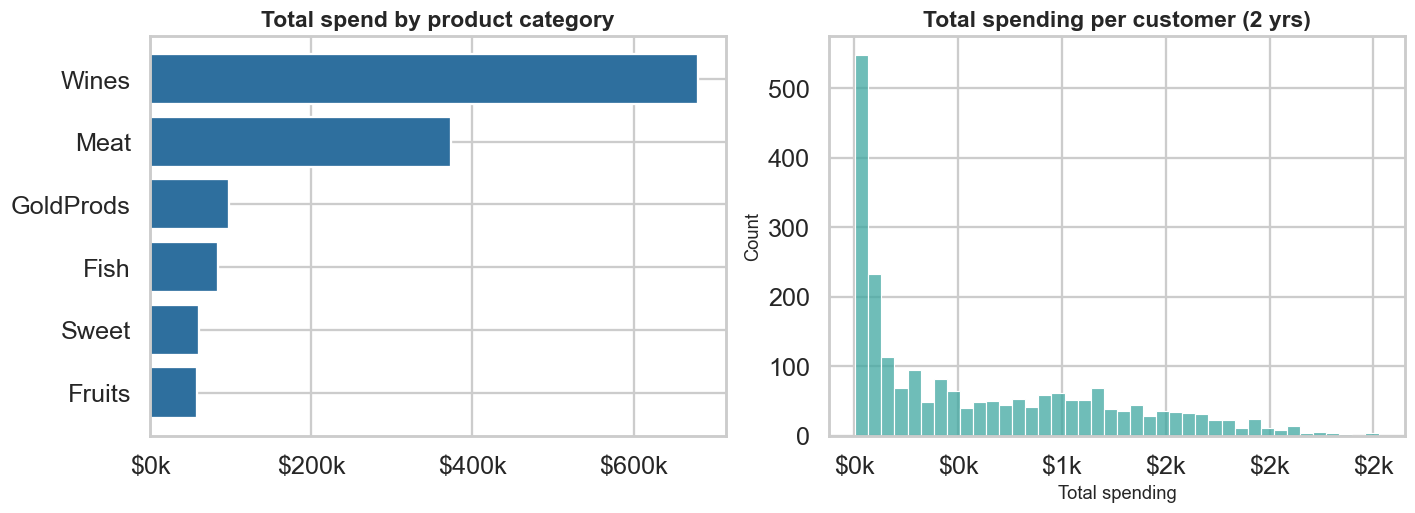

Share of wallet:
MntWines            50.2
MntMeatProducts     27.6
MntGoldProds         7.3
MntFishProducts      6.2
MntSweetProducts     4.5
MntFruits            4.3
dtype: float64


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

cat_spend = df[SPEND].sum().sort_values(ascending=True)
labels = [c.replace("Mnt", "").replace("Products", "") for c in cat_spend.index]
ax[0].barh(labels, cat_spend.values, color=BLUE)
ax[0].set_title("Total spend by product category")
ax[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))

sns.histplot(df["TotalSpending"], bins=40, color=TEAL, ax=ax[1])
ax[1].set_title("Total spending per customer (2 yrs)")
ax[1].set_xlabel("Total spending")
ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
plt.tight_layout()
plt.show()

print("Share of wallet:")
print((df[SPEND].sum() / df[SPEND].sum().sum() * 100).round(1).sort_values(ascending=False))

**Read:** spending is dominated by **wine and meat**, which together are roughly half of all revenue. The
per-customer spending distribution is heavily **right-skewed** — a minority of high-spenders account for a
large share of revenue. That skew is exactly the kind of structure a tree-based model exploits, and it
hints that *spend* will be a strong response signal.

### Campaign & channel behaviour — how do they engage?

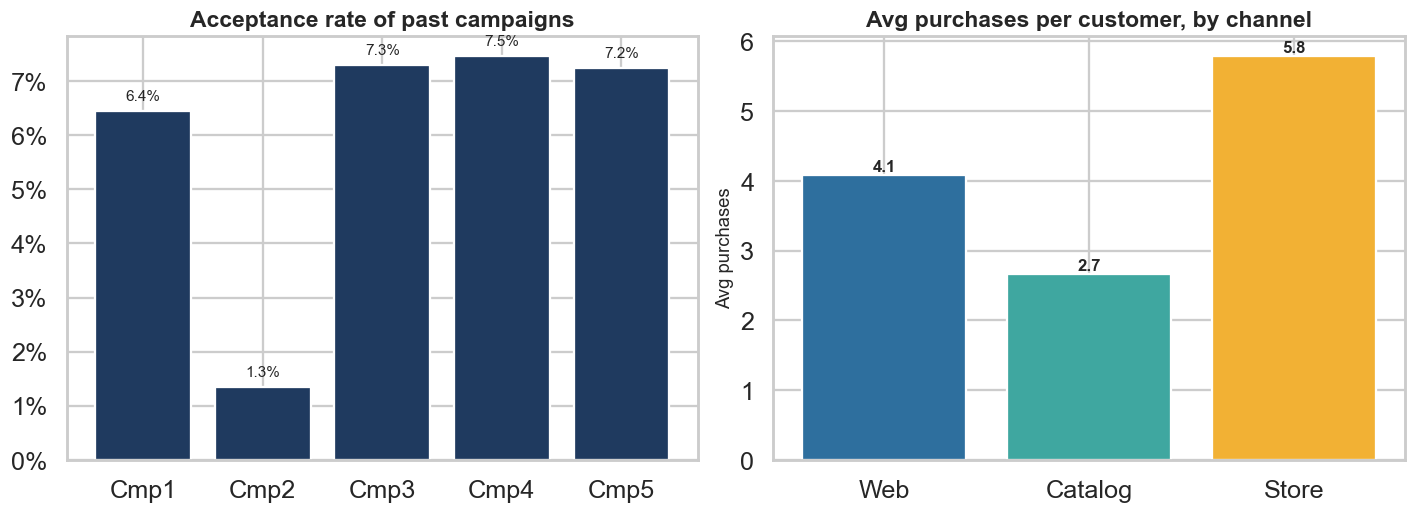

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

cmp_rates = df[CMP].mean().sort_index()
ax[0].bar([c.replace("Accepted", "") for c in cmp_rates.index],
          cmp_rates.values, color=NAVY)
for i, v in enumerate(cmp_rates.values):
    ax[0].text(i, v + 0.002, f"{v:.1%}", ha="center", fontsize=10)
ax[0].set_title("Acceptance rate of past campaigns")
pct_axis(ax[0])

chan = df[["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]].mean()
ax[1].bar(["Web", "Catalog", "Store"], chan.values, color=[BLUE, TEAL, GOLD])
for i, v in enumerate(chan.values):
    ax[1].text(i, v + 0.05, f"{v:.1f}", ha="center", fontweight="bold")
ax[1].set_title("Avg purchases per customer, by channel")
ax[1].set_ylabel("Avg purchases")
plt.tight_layout()
plt.show()

**Read:** past campaigns landed with only **3–7%** of customers (Campaign 2 flopped at ~1%), which is why
better targeting matters so much — there's a lot of headroom. On channels, the **store** is the workhorse,
but **catalog** buyers, though fewer, turn out to be unusually responsive (we'll confirm this below).

### Responders vs non-responders — the comparison that matters

This is the heart of the EDA: for each promising signal, do responders look different from everyone else?

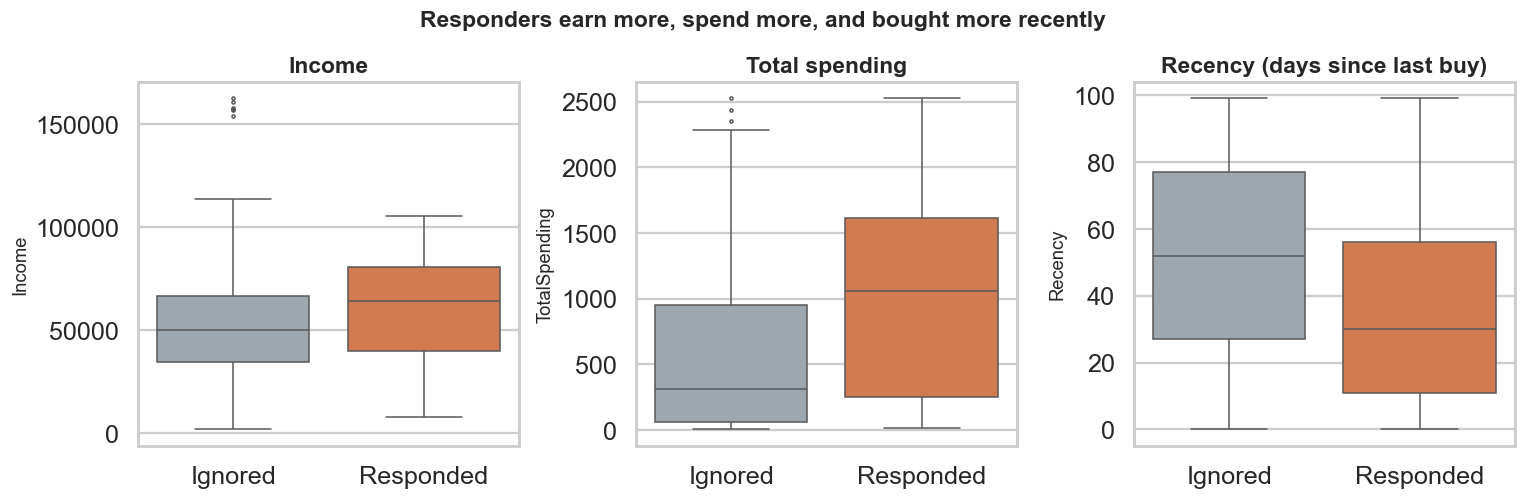

           Income  TotalSpending  Recency  TotalPurchases  NumCatalogPurchases
Response                                                                      
0         50489.0          539.0     52.0            14.0                  2.0
1         60210.0          987.0     35.0            18.0                  4.0


In [15]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.6))
for a, col, title in zip(
        ax,
        ["Income", "TotalSpending", "Recency"],
        ["Income", "Total spending", "Recency (days since last buy)"]):
    sns.boxplot(data=df, x="Response", y=col, hue="Response",
                palette=RESP_PALETTE, legend=False, ax=a, fliersize=2)
    a.set_title(title)
    a.set_xticklabels(["Ignored", "Responded"])
    a.set_xlabel("")
plt.suptitle("Responders earn more, spend more, and bought more recently",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(df.groupby("Response")[["Income", "TotalSpending", "Recency",
      "TotalPurchases", "NumCatalogPurchases"]].mean().round(0))

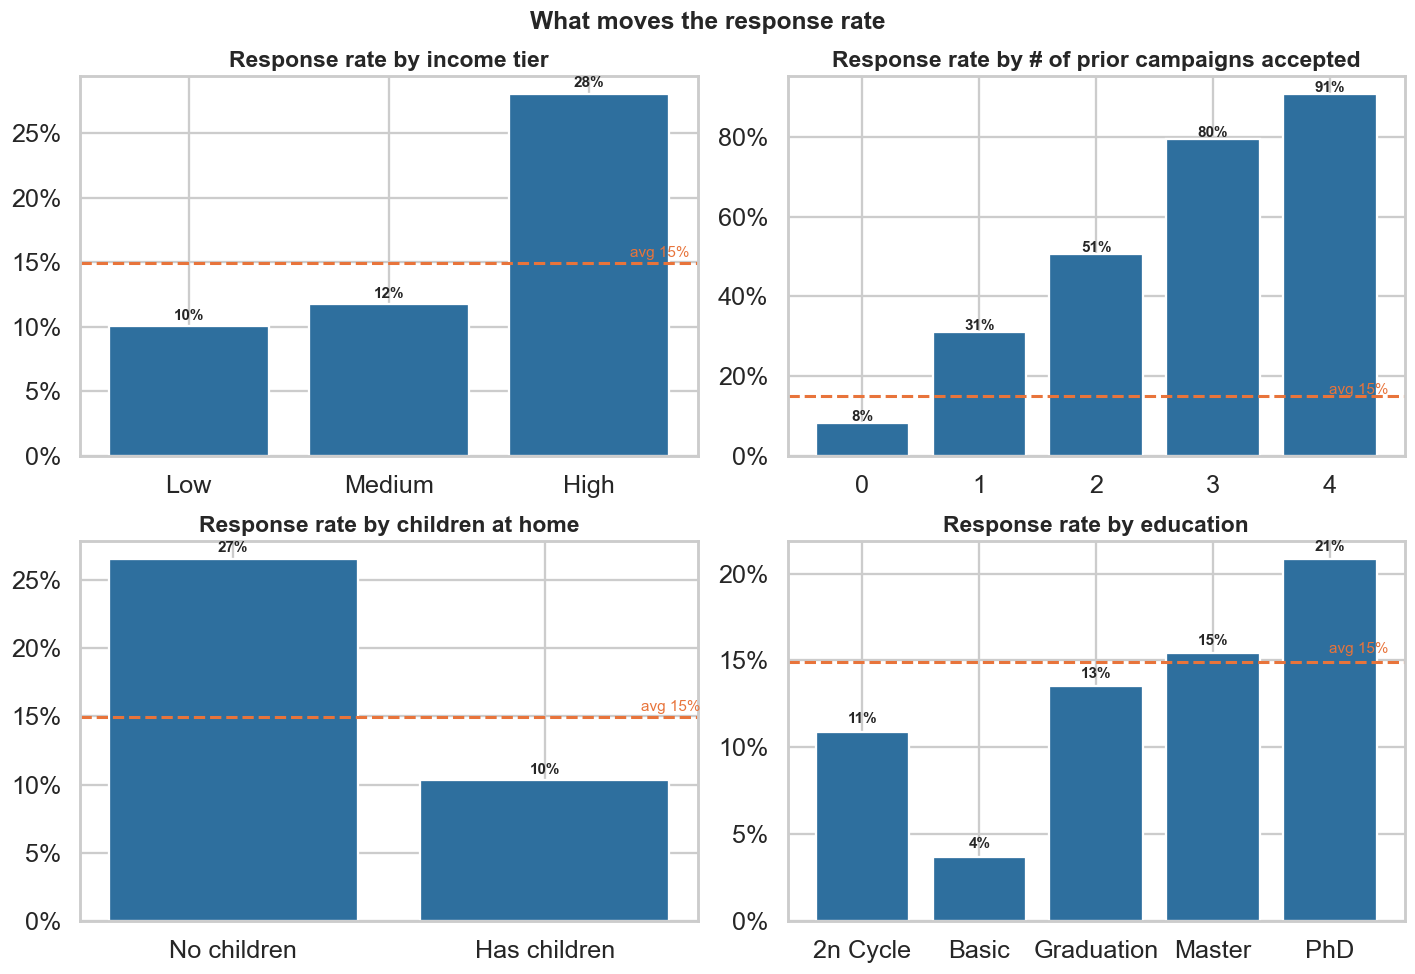

In [16]:
# Response rate across the most actionable segments
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

def rate_bar(col, a, title, order=None):
    g = df.groupby(col, observed=True)["Response"].mean()
    if order is not None:
        g = g.reindex(order)
    bars = a.bar(g.index.astype(str), g.values, color=BLUE)
    a.axhline(overall_rate, color=CORAL, ls="--", lw=2)
    a.text(len(g) - 0.5, overall_rate + 0.005, f"avg {overall_rate:.0%}",
           color=CORAL, ha="right", fontsize=10)
    for b, v in zip(bars, g.values):
        a.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.0%}",
               ha="center", fontweight="bold", fontsize=10)
    a.set_title(title)
    pct_axis(a)

rate_bar("IncomeSegment", ax[0, 0], "Response rate by income tier", ["Low", "Medium", "High"])
rate_bar("TotalAcceptedCmp", ax[0, 1], "Response rate by # of prior campaigns accepted")
rate_bar("HasChildren", ax[1, 0], "Response rate by children at home")
ax[1, 0].set_xticklabels(["No children", "Has children"])
rate_bar("Education", ax[1, 1], "Response rate by education")
plt.suptitle("What moves the response rate", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

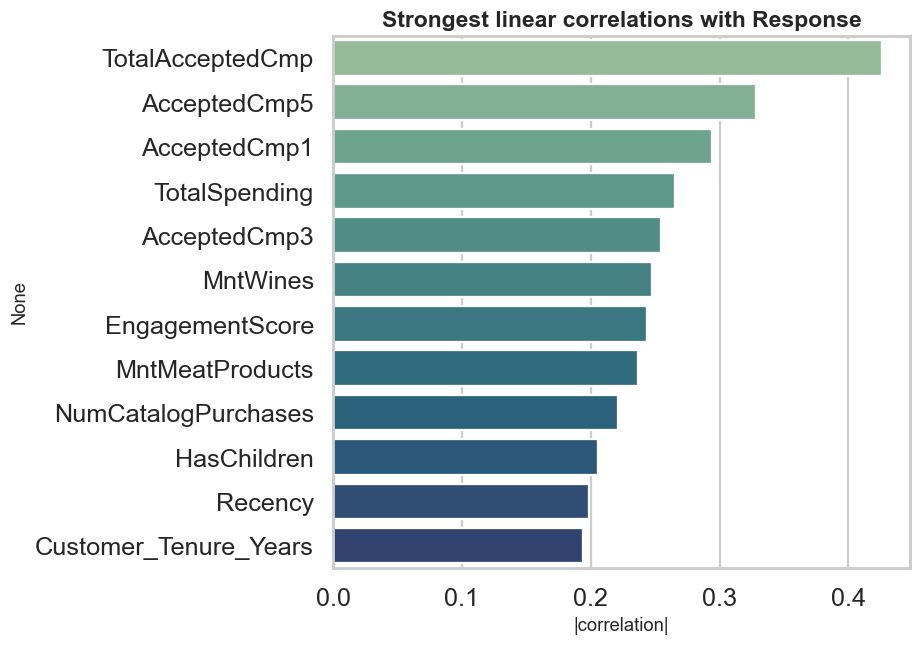

In [17]:
# Correlation of numeric signals with Response
num = df.select_dtypes("number")
corr = num.corr(numeric_only=True)["Response"].drop("Response").abs().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.barplot(x=corr.values, y=corr.index, palette="crest", hue=corr.index, legend=False, ax=ax)
ax.set_title("Strongest linear correlations with Response")
ax.set_xlabel("|correlation|")
plt.tight_layout()
plt.show()

**Read:** prior campaign acceptance dominates everything else, with spending and income close behind. Note
what's *missing*: `NumWebVisitsMonth` barely correlates with response — frequent browsing is **not** the
same as buying, a useful myth to bust before anyone over-invests in web-visit retargeting.

# Key Insights

Five findings, each with the observation, the evidence in the data, and what the business should do about it.

---

### Insight 1 — Past behaviour is destiny: prior responders are the goldmine
**Observation.** The single best predictor of a "yes" is whether the customer said "yes" before.
**Evidence.** Customers who accepted **at least one** prior campaign respond at **40.7%**, versus **8.2%**
for those who never have — a **2.7x lift**. It climbs monotonically: one prior accept → 31%, two → 51%,
three → **80%**. It's also the #1 linear correlate with `Response` (r ≈ 0.43).
**Business meaning.** Your warmest list already exists. Before spending a cent on prospecting, re-target
the ~460 customers with any prior acceptance — they convert at roughly 3x the base rate.

---

### Insight 2 — Money talks: high-income customers respond ~2x more
**Observation.** Response rises sharply with income tier.
**Evidence.** High-income customers (>\$70k) respond at **28.1%** vs **10.0%** for low-income (<\$35k) —
an **1.9x lift**. Combine high income *and* a prior acceptance and the rate jumps to **47%** (3.2x).
**Business meaning.** Premium customers are both more likely to convert and worth more per conversion.
They deserve a higher-touch, higher-value offer — not the same coupon everyone gets.

---

### Insight 3 — Recency wins: recent buyers are warm, lapsed buyers are cold
**Observation.** The more recently a customer purchased, the more likely they respond.
**Evidence.** Responders last purchased **~35 days** ago on average; non-responders **~52 days** ago.
**Business meaning.** Strike while the relationship is warm. Trigger campaigns *off* recent purchases
(e.g. within 30 days) rather than blasting the whole base on a fixed calendar.

---

### Insight 4 — Childless households respond far more
**Observation.** Having kids or teens at home suppresses response.
**Evidence.** Customers with **no children** respond at **26.5%** vs **10.3%** for those with children —
a **1.8x** gap. (Childless households here also skew higher-income and higher-spend.)
**Business meaning.** Household composition is a cheap, always-available filter. Weight targeting toward
no-children, higher-disposable-income households for premium offers.

---

### Insight 5 — Channel tells you who's listening: catalog buyers over-respond
**Observation.** Catalog engagement separates responders from the rest more than web or store.
**Evidence.** Responders average **4.2** catalog purchases vs **2.4** for non-responders; catalog is among
the top correlates while `NumWebVisitsMonth` is essentially flat (responders and non-responders both
average ~5.3 visits/month).
**Business meaning.** Catalog-active customers are a high-yield segment — keep investing there. And don't
be fooled by raw web traffic: visits ≠ intent, so prioritise *purchase* signals over *browsing* signals.

---

### Bonus — Education and life-stage nuances
PhD holders respond at **20.8%** vs **3.7%** for Basic-education customers; single/divorced/widowed
customers out-respond partnered ones; and response is **U-shaped in age** (the under-35s and the 65+ both
over-index). Useful secondary filters when refining a segment.

# 4 — Feature Engineering

Raw columns describe a customer; *engineered* features describe their **behaviour and value**, which is
what actually predicts response. The functions in Section 3 already built these — here is the why and the
expected business value of each, well beyond the required minimum of five.

| # | Feature | How it's built | Why it's created / business value |
|---|---------|----------------|-----------------------------------|
| 1 | **Age** | `2015 − Year_Birth` | People reason in age, not birth year; enables life-stage segmentation |
| 2 | **TotalSpending** | Sum of the 6 `Mnt*` columns | A single "customer value" number; high spenders convert more |
| 3 | **TotalPurchases** | Sum of web + catalog + store + deals | Overall purchase frequency / activity level |
| 4 | **SpendingPerPurchase** | `TotalSpending ÷ TotalPurchases` | Average basket value — separates premium from bargain shoppers |
| 5 | **TotalAcceptedCmp** | Sum of `AcceptedCmp1–5` | Loyalty / proven responsiveness — the strongest single signal |
| 6 | **Customer_Tenure_Years** | `(2015-01-01 − Dt_Customer)` | Long-standing vs new customers behave differently |
| 7 | **EngagementScore** | `TotalPurchases + 3 × TotalAcceptedCmp` | One composite of activity *and* responsiveness (see below) |
| 8 | **Children / HasChildren** | `Kidhome + Teenhome` | Household lifestyle & disposable-income proxy |
| 9 | **IncomeSegment** | Bins: <35k / 35–70k / >70k | Lets leadership reason in tiers, not raw dollars |
| 10 | **AgeGroup** | Bins: ≤35 / 36–50 / 51–65 / 65+ | Readable demographic cross-tabs |

**The EngagementScore formula, explained.** I wanted one interpretable number that rewards two behaviours:
transacting and responding. `EngagementScore = TotalPurchases + 3 × TotalAcceptedCmp`. The **3x weight** on
prior acceptances is deliberate — Insight 1 showed that a single prior acceptance is worth far more than a
single extra purchase in predicting future response, so it should count for more. It's a transparent,
explainable proxy a marketer can sanity-check by hand, not a black box.

In [18]:
engineered_cols = ["Age", "TotalSpending", "TotalPurchases", "SpendingPerPurchase",
                   "TotalAcceptedCmp", "Customer_Tenure_Years", "EngagementScore",
                   "Children", "IncomeSegment", "AgeGroup"]
df[engineered_cols].head()

,Age,TotalSpending,TotalPurchases,SpendingPerPurchase,TotalAcceptedCmp,Customer_Tenure_Years,EngagementScore,Children,IncomeSegment,AgeGroup
0,58,1617,25,64.680000,0,2.324435,25,0,Medium,51-65
1,61,27,6,4.500000,0,0.818617,6,2,Medium,51-65
2,50,776,21,36.952381,0,1.363450,21,0,High,36-50
3,31,53,8,6.625000,0,0.889802,8,1,Low,<=35
4,34,422,19,22.210526,0,0.950034,19,1,Medium,<=35


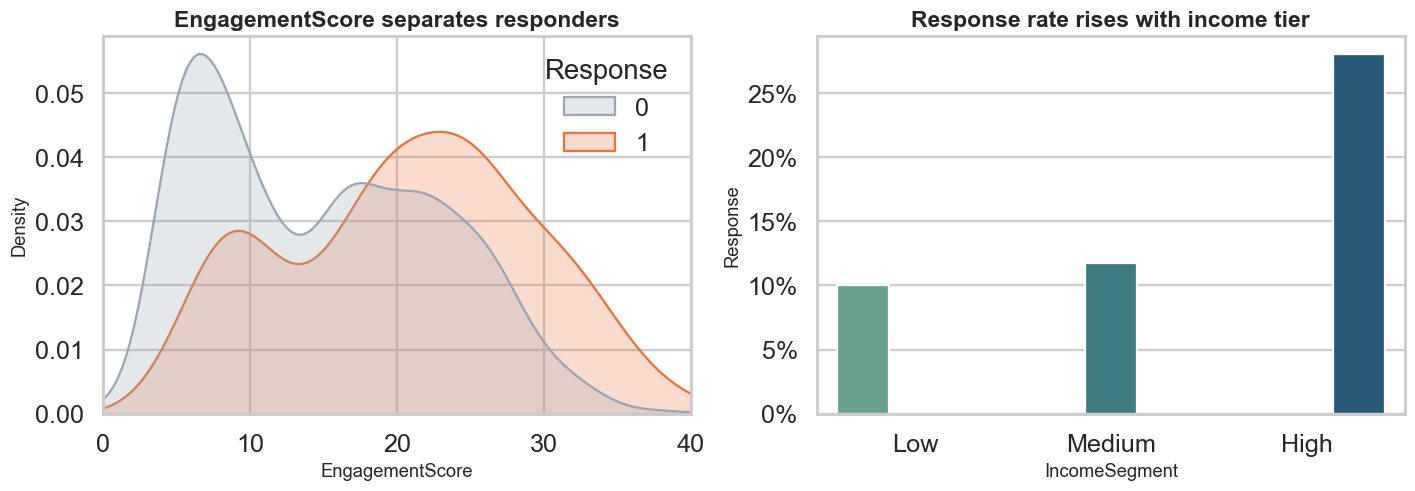

In [19]:
# Quick validation that the headline features actually separate responders
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
sns.kdeplot(data=df, x="EngagementScore", hue="Response", palette=RESP_PALETTE,
            fill=True, common_norm=False, ax=ax[0])
ax[0].set_title("EngagementScore separates responders")
ax[0].set_xlim(0, 40)

sns.barplot(data=df, x="IncomeSegment", y="Response", order=["Low", "Medium", "High"],
            palette="crest", hue="IncomeSegment", legend=False, ax=ax[1], errorbar=None)
ax[1].set_title("Response rate rises with income tier")
pct_axis(ax[1])
plt.tight_layout()
plt.show()

**Read:** responders (coral) sit clearly to the right on EngagementScore, and response climbs step-wise
across income tiers — confirming both engineered features carry real signal before we even fit a model.

# 5 — Data Preprocessing

The golden rule here is **no data leakage**: every transformation that *learns* from the data (the median
for imputing income, the mean/std for scaling, the categories for encoding) must be fit on the **training
set only**, then applied to the test set. We guarantee that by wrapping all of it in a scikit-learn
`Pipeline` and only ever calling `.fit()` on training data.

**The plan, step by step**

- **Missing values** — `Income` (24 rows) is median-imputed *inside* the pipeline. Median, not mean, so the
  income skew doesn't drag the fill value upward.
- **Outliers** — already removed structurally (the impossible ages and the \$666k income). Median imputation
  and tree models are robust to the rest.
- **Encoding** — `Education` and `Marital_Status` are one-hot encoded, with `handle_unknown="ignore"` so a
  never-before-seen category at prediction time can't crash the model.
- **Scaling** — applied **only for Logistic Regression** (which is distance/scale-sensitive). Random Forest
  and XGBoost are scale-invariant, so we skip it there and keep their splits interpretable.
- **What we feed the model** — engineered behaviour features + the legitimate prior-campaign signals. The
  prior `AcceptedCmp*` flags are known *before* the new campaign, so they're fair game (no leakage). We
  exclude IDs, raw dates, and the target.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

NUMERIC = ["Income", "Recency", "Age", "Children", "TotalSpending", "TotalPurchases",
           "SpendingPerPurchase", "TotalAcceptedCmp", "Customer_Tenure_Years",
           "EngagementScore", "NumWebVisitsMonth", "NumWebPurchases",
           "NumCatalogPurchases", "NumStorePurchases", "NumDealsPurchases"] + SPEND
CATEGORICAL = ["Education", "Marital_Status"]
FEATURES = NUMERIC + CATEGORICAL

X = df[FEATURES].copy()
y = df["Response"].astype(int)

def make_preprocessor(scale):
    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), NUMERIC),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
         CATEGORICAL),
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

print(f"Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows")
print(f"Train response rate: {y_train.mean():.1%}   Test response rate: {y_test.mean():.1%}")
print(f"Model inputs: {len(FEATURES)} columns ({len(NUMERIC)} numeric, {len(CATEGORICAL)} categorical)")

Train: 1,789 rows   Test: 448 rows
Train response rate: 14.9%   Test response rate: 15.0%
Model inputs: 23 columns (21 numeric, 2 categorical)


**Read:** an 80/20 **stratified** split keeps the 15% response rate identical in train and test, so the
test score is a fair estimate of real-world performance. Imputation, encoding, and scaling are now sealed
inside each model's pipeline — they will be re-fit on every cross-validation fold automatically.

# 6 — Model Building

I train three models, deliberately spanning the complexity spectrum from "fully explainable" to "best
raw performance". All three are told to handle the class imbalance.

### Model 1 — Logistic Regression (the transparent baseline)
- **Why chosen.** It's the honest yardstick. If a simple linear model already ranks customers well, we know
  the signal is strong; anything fancier must *earn* its added complexity.
- **Advantages.** Fully interpretable (coefficients = direction & strength of each driver), fast, calibrated
  probabilities, hard to overfit.
- **Limitations.** Assumes roughly linear, additive effects; misses interactions (e.g. *high income **and**
  recent purchase*) unless we hand-build them.

### Model 2 — Random Forest (robust non-linear workhorse)
- **Why chosen.** Captures non-linearities and interactions automatically, needs little tuning, and is
  resistant to outliers and irrelevant features.
- **Advantages.** Strong out-of-the-box, gives feature importances, scale-invariant.
- **Limitations.** Larger memory footprint; less interpretable than a single tree; can be biased toward
  high-cardinality features.

### Model 3 — XGBoost (the performance pick)
- **Why chosen.** Gradient-boosted trees are the go-to for tabular problems like this and usually top the
  leaderboard; `scale_pos_weight` handles the imbalance cleanly.
- **Advantages.** Typically best accuracy/AUC, regularised against overfitting, handles mixed feature types.
- **Limitations.** More hyperparameters to get right; less transparent (we lean on feature importance and
  could add SHAP for case-level explanations).

We evaluate with a stratified **80/20 train/test split** for the headline numbers and **5-fold stratified
cross-validation** (ROC-AUC) on the training set to confirm the ranking is stable, not a fluke of one split.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_XGB = False

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()   # ~5.7 : 1

models = {
    "Logistic Regression": Pipeline([
        ("prep", make_preprocessor(scale=True)),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("prep", make_preprocessor(scale=False)),
        ("model", RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                          class_weight="balanced", n_jobs=-1, random_state=42)),
    ]),
}
if HAS_XGB:
    models["XGBoost"] = Pipeline([
        ("prep", make_preprocessor(scale=False)),
        ("model", XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=4,
                                subsample=0.9, colsample_bytree=0.9,
                                scale_pos_weight=pos_weight, eval_metric="logloss",
                                random_state=42, n_jobs=-1)),
    ])
else:
    models["Gradient Boosting"] = Pipeline([
        ("prep", make_preprocessor(scale=False)),
        ("model", GradientBoostingClassifier(random_state=42)),
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("5-fold cross-validated ROC-AUC on the training set:\n")
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"  {name:<22} {scores.mean():.3f} ± {scores.std():.3f}")
    pipe.fit(X_train, y_train)   # fit on full training set for test evaluation
print("\nAll models trained.")

5-fold cross-validated ROC-AUC on the training set:

  Logistic Regression    0.895 ± 0.022


  Random Forest          0.884 ± 0.014


  XGBoost                0.898 ± 0.016



All models trained.


**Read:** all three cross-validate around **0.88–0.90 ROC-AUC** with tight error bars — the signal is real
and stable, not an artefact of one lucky split. XGBoost and Logistic Regression are neck-and-neck on the
CV ranking; the test set below breaks the tie on the metrics that matter for action.

# 7 — Model Evaluation

We score every model on the held-out test set across the full metric suite, then look at confusion
matrices and ROC curves before crowning a winner.

In [22]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)

rows, preds = [], {}
for name, pipe in models.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    preds[name] = (pred, proba)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results = pd.DataFrame(rows).set_index("Model").sort_values("ROC-AUC", ascending=False)
results.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost,0.888,0.631,0.612,0.621,0.904
Random Forest,0.888,0.718,0.418,0.528,0.894
Logistic Regression,0.806,0.415,0.731,0.530,0.883


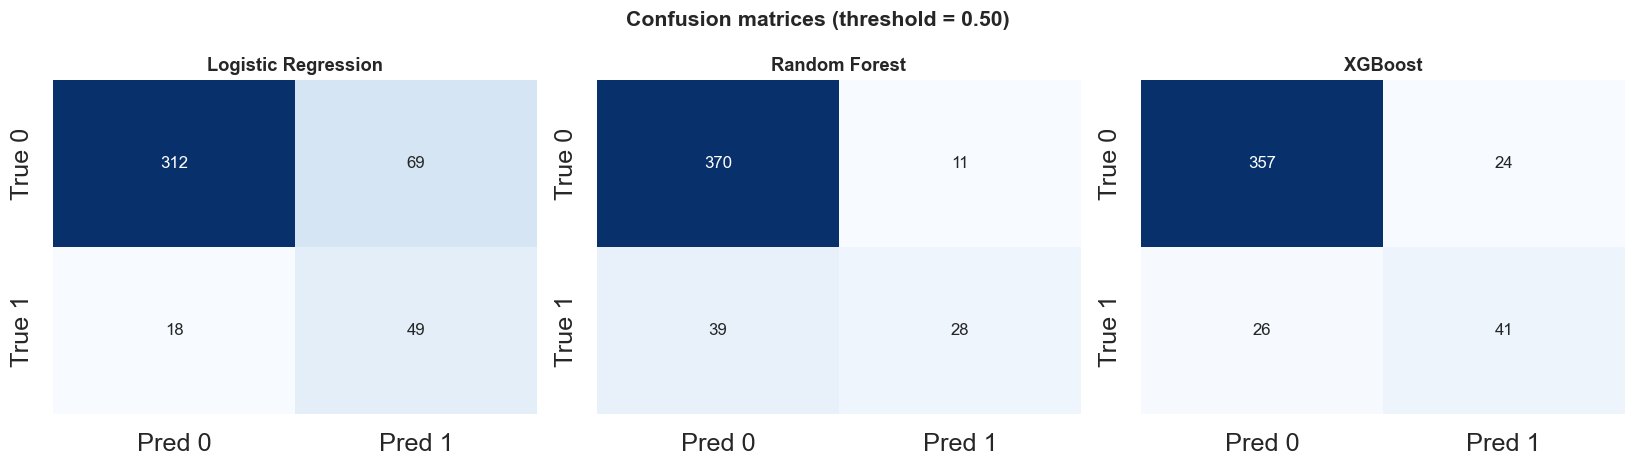

In [23]:
# Confusion matrices (default 0.5 threshold)
n = len(models)
fig, ax = plt.subplots(1, n, figsize=(5 * n, 4.3))
for a, (name, (pred, _)) in zip(np.atleast_1d(ax), preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=a,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    a.set_title(name, fontsize=12)
plt.suptitle("Confusion matrices (threshold = 0.50)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

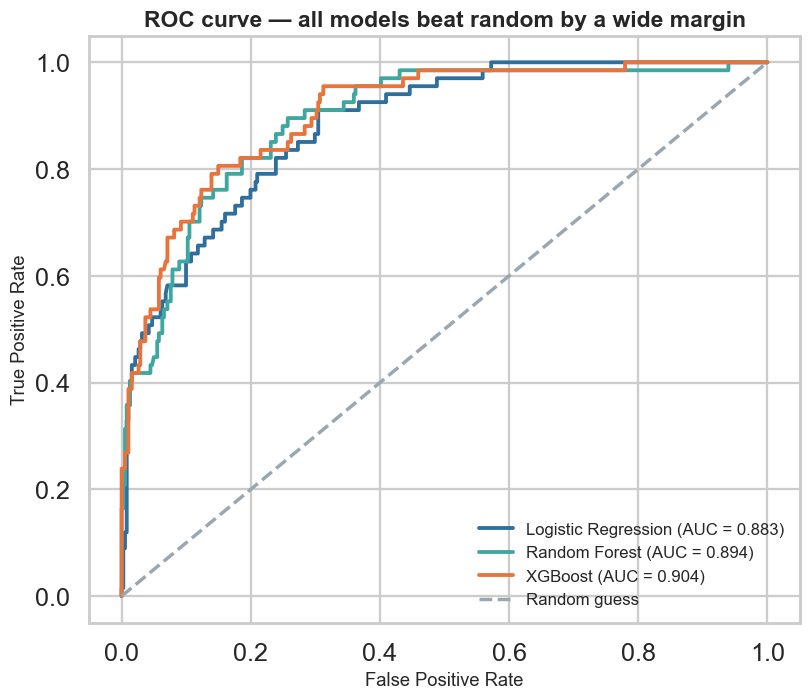

In [24]:
# ROC curve comparison
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for (name, (_, proba)), c in zip(preds.items(), [BLUE, TEAL, CORAL]):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=c, lw=2.5,
            label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})")
ax.plot([0, 1], [0, 1], "--", color=GREY, label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve — all models beat random by a wide margin")
ax.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

### Picking the winner

| Model | What the test set shows |
|-------|-------------------------|
| **XGBoost** | **Best ROC-AUC (~0.90) and best F1 (~0.62).** The strongest *ranker* of customers and the best balance of precision and recall. |
| Random Forest | Highest precision (~0.72) but low recall (~0.42) — it's cautious, catching fewer than half the responders. |
| Logistic Regression | Highest recall (~0.73) but low precision (~0.42) — it casts a wide, noisy net. |

**Decision: XGBoost.** Because the model's real job is to **rank** customers so we can contact the most
promising first, ROC-AUC is the headline metric — and XGBoost leads it while also posting the best F1.
Crucially, its 0.5-threshold behaviour isn't the final word: the probability output lets us *choose* the
operating point to match the budget, which is exactly what we do next.

# 8 — Marketing Perspective: which metric actually matters?

Metrics are not abstract here — each one maps to money.

- **A false positive** = we contact someone who won't respond → **wasted contact cost** (and mild brand
  fatigue). In this dataset the cost is **\$3 per contact**.
- **A false negative** = we *skip* someone who would have responded → **lost sale**. Each accepted offer is
  worth **\$11**.

**Precision** = of those we contact, how many respond (controls wasted spend). **Recall** = of all real
responders, how many we catch (controls missed revenue). **F1** balances the two.

So which to prioritise? It depends on the economics, and here the economics are lopsided: a missed
responder (\$11 of value forgone) hurts more than a wasted contact (\$3). That argues for **leaning toward
recall** — but not blindly, because contacting everyone wastes the \$3 many times over. The right answer
isn't to pick a metric in the abstract; it's to **tune the decision threshold to maximise expected
profit**, using the model's probability scores. Let's compute that curve directly.

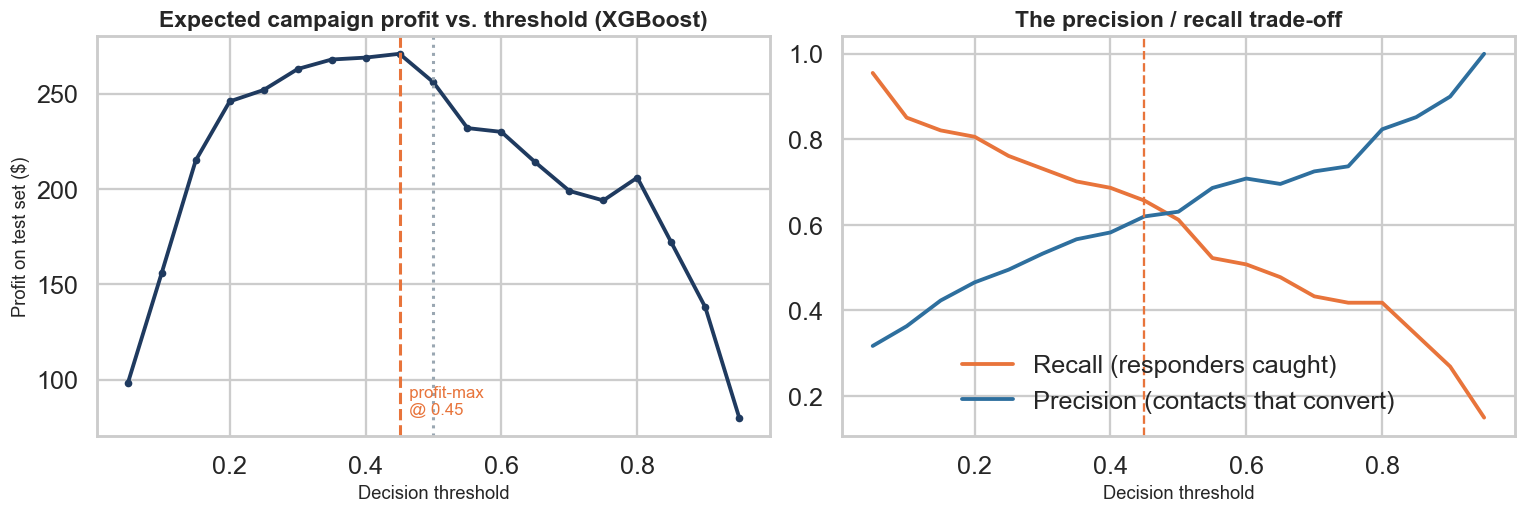

Best model: XGBoost
Profit-maximising threshold ≈ 0.45 (vs. the naive 0.50).


In [25]:
# Sweep the decision threshold on the best model and compute campaign profit
best_name = results.index[0]
_, best_proba = preds[best_name]
yt = y_test.to_numpy()

REVENUE, COST = 11.0, 3.0      # the dataset's own unit economics (Z_Revenue, Z_CostContact)
ths = np.linspace(0.05, 0.95, 19)
prof, recalls, precs = [], [], []
for t in ths:
    p = (best_proba >= t).astype(int)
    tp = int(((p == 1) & (yt == 1)).sum())
    fp = int(((p == 1) & (yt == 0)).sum())
    fn = int(((p == 0) & (yt == 1)).sum())
    prof.append(tp * REVENUE - (tp + fp) * COST)
    recalls.append(tp / (tp + fn) if (tp + fn) else 0)
    precs.append(tp / (tp + fp) if (tp + fp) else 0)

best_t = ths[int(np.argmax(prof))]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].plot(ths, prof, color=NAVY, lw=2.5, marker="o", ms=4)
ax[0].axvline(best_t, color=CORAL, ls="--", lw=2)
ax[0].axvline(0.5, color=GREY, ls=":", lw=2)
ax[0].text(best_t, min(prof), f"  profit-max\n  @ {best_t:.2f}", color=CORAL, va="bottom")
ax[0].set_title(f"Expected campaign profit vs. threshold ({best_name})")
ax[0].set_xlabel("Decision threshold"); ax[0].set_ylabel("Profit on test set ($)")

ax[1].plot(ths, recalls, color=CORAL, lw=2.5, label="Recall (responders caught)")
ax[1].plot(ths, precs, color=BLUE, lw=2.5, label="Precision (contacts that convert)")
ax[1].axvline(best_t, color=CORAL, ls="--", lw=1.5)
ax[1].set_title("The precision / recall trade-off")
ax[1].set_xlabel("Decision threshold"); ax[1].legend()
plt.tight_layout()
plt.show()

print(f"Best model: {best_name}")
print(f"Profit-maximising threshold ≈ {best_t:.2f} (vs. the naive 0.50).")

**Conclusion — prioritise recall, operationalised through the threshold.** Because a missed responder costs
more than a wasted contact, the profit curve peaks at a threshold **below** the naive 0.50 — i.e. it pays
to contact *more* people and accept some waste in order to catch more responders. In practice:

1. **Use ROC-AUC to choose the model** (it's threshold-independent and measures ranking quality — the thing
   we actually rely on).
2. **Use the profit curve to choose the threshold**, given the campaign's real cost and margin and any
   budget cap. When economics are unknown, default to a **recall-leaning** operating point (e.g. F2 instead
   of F1), since the asymmetric costs here favour catching responders over avoiding waste.

This is the single most important translation in the project: *the metric isn't fixed — the business
economics pick it.*

# 9 — Feature Importance: what drives a "yes"?

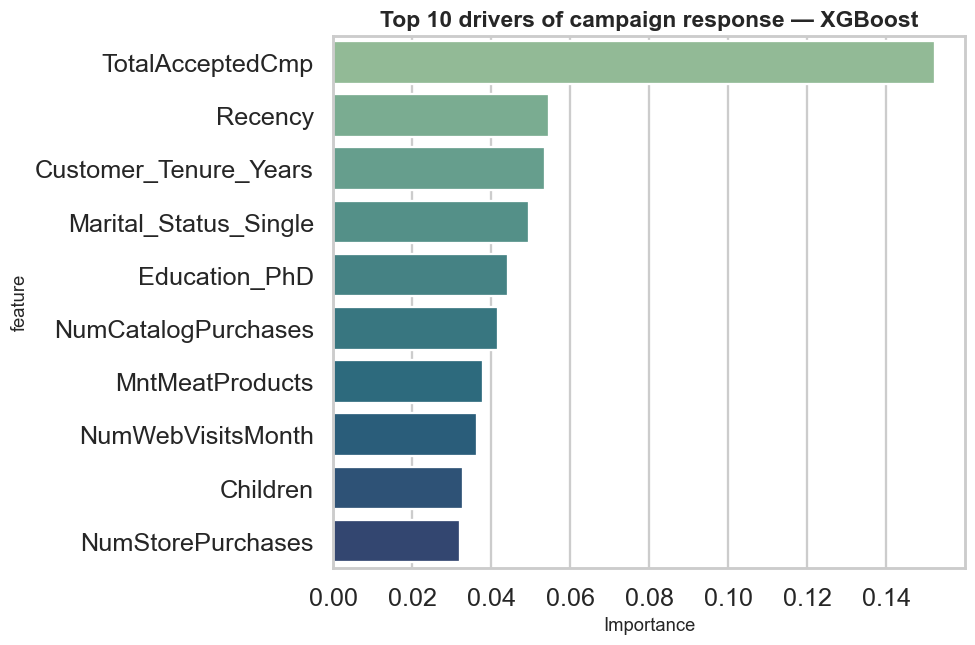

,feature,importance
0,TotalAcceptedCmp,0.152247
1,Recency,0.054625
2,Customer_Tenure_Years,0.053581
3,Marital_Status_Single,0.049604
4,Education_PhD,0.044238
5,NumCatalogPurchases,0.041749
6,MntMeatProducts,0.038022
7,NumWebVisitsMonth,0.036469
8,Children,0.032935
9,NumStorePurchases,0.032065


In [26]:
best_pipe = models[best_name]
prep = best_pipe.named_steps["prep"]
model = best_pipe.named_steps["model"]
names = [n.split("__", 1)[-1] for n in prep.get_feature_names_out()]
imp = (pd.DataFrame({"feature": names, "importance": model.feature_importances_})
       .sort_values("importance", ascending=False).head(10).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=imp, x="importance", y="feature", palette="crest",
            hue="feature", legend=False, ax=ax)
ax.set_title(f"Top 10 drivers of campaign response — {best_name}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
imp

**What drives campaign response — in business language.**

- **Prior campaign acceptances (`TotalAcceptedCmp`) tower over everything.** Past "yes" → future "yes". The
  most valuable thing you own is a list of people who already responded once.
- **Recency** — how recently they bought. Warm customers convert; lapsed ones don't.
- **Customer tenure** — relationship length shapes responsiveness.
- **Marital status (single) and education (PhD)** — single, highly-educated customers over-index.
- **Catalog & store purchases, meat/wine spend, income** — the affluent, high-engagement core.
- **Children at home** — fewer kids, higher response.

These aren't just model internals; they're a **targeting checklist**. The most responsive customer is a
**recent, affluent, previously-responsive buyer with no children** — and the model quantifies exactly how
much each trait shifts the odds.

# 10 — Business Recommendations

Translating the analysis into an action plan leadership can run this quarter.

### Customer Targeting — *who to contact first*
Rank the entire base by the model's response probability and work down the list until the budget is spent.
The top of that list will be dominated by the traits we proved matter: **prior responders, high-income,
recent buyers, childless, catalog-active.** Start with the ~460 customers who've accepted any prior
campaign — they convert at ~3x the base rate and cost nothing new to identify.

### Budget Allocation — *where the money goes*
Stop spending uniformly. Concentrate budget on the **top 2–3 deciles** of predicted probability, where the
responders actually are. The profit curve in Section 8 shows the contact list should be set by *expected
profit per contact*, not by reaching everyone — reallocating spend from the bottom half (which barely
responds) to the top decile is the fastest ROI win available.

### Personalization — *who gets the bespoke treatment*
- **High-income + prior responders (≈47% response):** premium, higher-value offers and early access — not
  a generic coupon.
- **Recent buyers:** trigger campaigns within ~30 days of a purchase while the relationship is warm.
- **Catalog-active customers:** keep feeding the channel they actually convert through.
- **Price-sensitive / deal-driven segments:** discount-led messaging, kept separate from the premium track.

### Campaign Optimization — *how to lift the response rate*
- Move from **calendar-based blasts to behaviour-triggered** sends (recency, recent browse-to-buy).
- **Tune the contact threshold to the campaign's economics** (Section 8) rather than defaulting to "contact
  the obvious few" or "contact everyone".
- **A/B test** creative and offer depth within the top deciles to keep improving conversion.

### ROI Improvement — *how to make marketing pay more*
The mechanism is simple: the same budget, pointed at customers who respond ~3x more often, produces far
more accepted offers per dollar. Track **incremental response rate** and **profit per contact** against a
random-targeting control so the lift is provable to finance, not just asserted.

# 11 — Deployment Risks: *if this model shipped tomorrow, what could go wrong?*

A model is a living asset, not a one-off result. Four failure modes and how I'd handle each:

### False Positives — contacting people who won't respond
- **Impact.** Wasted contact cost (\$3 each here) and, at scale, brand fatigue / unsubscribes that erode the
  list over time.
- **Mitigation.** **Threshold tuning** to the campaign's economics (Section 8), frequency caps per customer,
  and suppression lists. Monitor precision in production and pull back the threshold if waste creeps up.

### False Negatives — skipping people who would have responded
- **Impact.** Lost sales — the more expensive error here, since a missed responder (\$11) outweighs a wasted
  contact (\$3).
- **Mitigation.** **Recall-leaning operating point**, plus a small **random holdout** that's contacted
  regardless of score, so we keep measuring (and recovering) responders the model currently misses.

### Data Drift — the inputs change
- **Impact.** Income bands inflate, channel mix shifts, a feature pipeline upstream changes units — and the
  model degrades silently.
- **Mitigation.** A **monitoring pipeline** that tracks input distributions (population stability index) and
  output score distributions, with alerts when they move beyond tolerance. Schema/contract tests on the
  feature pipeline.

### Changing Customer Behaviour — the world moves on
- **Impact.** Post-promotion, post-recession, or seasonal shifts mean yesterday's responders aren't
  tomorrow's; accuracy decays.
- **Mitigation.** **Periodic retraining** on a rolling window (e.g. quarterly), champion/challenger testing
  before promotion, and tracking live response rate vs. the model's predicted rate as the canary.

**Cross-cutting safeguards.** Calibrate probabilities before using them as dollars; check fairness across
demographics so we're not systematically excluding a group; and keep a human-readable audit (feature
importance + SHOULD-add SHAP) so marketing trusts and can explain the targeting.

# 12 — Future Improvements: *what I'd do with one more week*

Prioritised by expected business impact, not by what's technically fun.

### 1. Business usage (highest impact)
- **Threshold/budget optimiser in production** so each campaign automatically picks its profit-maximising
  contact list — this is where the money is.
- **Customer segmentation** (e.g. K-Means / RFM on spend, recency, engagement) to pair the *who* with a
  matching *what* (offer), turning probabilities into tailored campaigns.
- **A/B testing framework** vs. a random-targeting control to prove incremental lift to finance.

### 2. Data (medium-high impact)
- Add **richer behavioural features**: email open/click, web session depth, time-since-last-campaign, and
  seasonality — browsing *intent* signals the current data lacks.
- Bring in **margin per product category** so we optimise profit, not just response.

### 3. Modelling (incremental impact)
- **Hyperparameter tuning** (Bayesian/Optuna) and **probability calibration** (isotonic) so scores are
  trustworthy dollars.
- **Feature selection** to prune redundant inputs for a leaner, faster model.
- **Ensembling / stacking** Logistic + XGBoost, and **SHAP** for per-customer explanations the marketing
  team can read.

The theme: I'd spend the week mostly on **turning the model into decisions** (segmentation, threshold
optimisation, experimentation), because the modelling is already good enough — the remaining upside is in
*usage*, not in chasing another point of AUC.

# 13 — Executive Summary
*For the Marketing Director — one page.*

**The situation.** Our last campaign reached the whole base but only **~15% responded**, so most of the
spend hit people who were never going to buy. We built a model that scores every customer's likelihood to
respond, so we can target instead of broadcast.

**Approach (one breath).** Cleaned 2,237 customer records → engineered behaviour features (spend, recency,
engagement, prior-campaign history) → trained and compared three models with leakage-free pipelines and
cross-validation → translated the winner into a targeting and budget plan.

**What we learned (the money insights).**
- **Past responders are gold:** customers who accepted a prior campaign respond at **41%** vs **8%** — a 3x
  list we already own.
- **Affluence pays:** high-income customers respond ~**2x** more; high-income *and* previously responsive →
  **47%**.
- **Recency & lifestyle matter:** recent buyers and childless, higher-disposable-income households respond
  far more; raw web traffic does **not** predict response.

**Best model.** **XGBoost** — **ROC-AUC ≈ 0.90**, F1 ≈ 0.62, cross-validated and stable. It ranks customers
well enough that a model-driven contact list dramatically out-converts random contacting, and its
probability output lets us set the contact threshold to **maximise profit** for any given budget.

**What leadership should do next.**
1. **Re-target the ~460 prior responders immediately** (highest-yield, zero new identification cost).
2. **Concentrate budget on the top 2–3 probability deciles**; stop spending on the unresponsive bottom half.
3. **Personalise by segment** — premium offers for high-income responders, recency-triggered sends for warm
   buyers, keep investing in catalog.
4. **Run it against a random-targeting control** so the lift is proven in dollars.

**Expected business impact.** Same budget, pointed at customers who respond ~3x more often → materially more
accepted offers per dollar, less wasted contact spend, and a repeatable, measurable targeting engine instead
of an annual guess. The model doesn't just predict response — it tells marketing **where the next dollar
earns the most.**

---
*Built with Python (pandas, scikit-learn, XGBoost). Reproducible end-to-end; an interactive Streamlit app
accompanies this notebook for live exploration and single-customer scoring.*